In [5]:
# ============================================================
# 1.2 探索性数据分析 & 用户画像前瞻
# CAAI-BDSC2023 社交图谱动态链接预测
# ============================================================
import os, glob, gc
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from pathlib import Path
from collections import Counter

# ── seaborn 样式（必须在字体设置之前，因为 set_style 会重置 font.family）──
sns.set_style("whitegrid")

# ── 中文字体设置：直接注册 SimHei 字体文件（在 seaborn 之后，不会被覆盖）──
_simhei_path = r"C:\Windows\Fonts\simhei.ttf"
if os.path.exists(_simhei_path):
    fm.fontManager.addfont(_simhei_path)
    _prop = fm.FontProperties(fname=_simhei_path)
    _font_name = _prop.get_name()
    plt.rcParams["font.family"] = _font_name
else:
    plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]

plt.rcParams["axes.unicode_minus"] = False

print(f"[字体] font.family = {plt.rcParams['font.family']}")

FIG_DIR = Path(r"D:\GNN\figures")
FIG_DIR.mkdir(exist_ok=True)

# 路径
BASE_DIR = Path(r"D:\GNN")
PROCESSED_DIR = BASE_DIR / "processed"

# ── 加载数据 ──────────────────────────────────────────
print("加载合并数据...")
df_all   = pd.read_pickle(PROCESSED_DIR / "share_merged.pkl")
df_train = pd.read_pickle(PROCESSED_DIR / "share_train.pkl")
df_final_train = pd.read_pickle(PROCESSED_DIR / "share_final_train.pkl")

# 合并两个训练集，用于行为聚合和图计算
# ignore_index 重置索引，避免两表索引重复
df_train_all = pd.concat([df_train, df_final_train], ignore_index=True)
# 时间整理，将表中的字符串等形式的时间，转变成能够供代码处理的"时间格式"
df_train_all["timestamp"] = pd.to_datetime(df_train_all["timestamp"])

print(f"总表:      {df_all.shape[0]:,} 行 × {df_all.shape[1]} 列")
print(f"train:     {df_train.shape[0]:,} 行")
print(f"final_train: {df_final_train.shape[0]:,} 行")
print(f"train_all: {df_train_all.shape[0]:,} 行 (用于特征聚合)")

# 基本的唯一值信息
print(f"\n训练集唯一用户 (inviter): {df_train_all['inviter_id'].nunique():,}")
print(f"训练集唯一用户 (voter):   {df_train_all['voter_id'].nunique():,}")
print(f"训练集唯一商品:           {df_train_all['item_id'].nunique():,}")
print(f"训练集时间跨度:           {df_train_all['timestamp'].min()} ~ {df_train_all['timestamp'].max()}")

print("\n✅ 1.2 数据加载完成")

[字体] font.family = ['SimHei']
加载合并数据...
总表:      954,941 行 × 16 列
train:     602,679 行
final_train: 118,424 行
train_all: 721,103 行 (用于特征聚合)

训练集唯一用户 (inviter): 19,612
训练集唯一用户 (voter):   98,974
训练集唯一商品:           372,685
训练集时间跨度:           2021-12-27 00:00:15 ~ 2022-12-06 10:42:08

✅ 1.2 数据加载完成


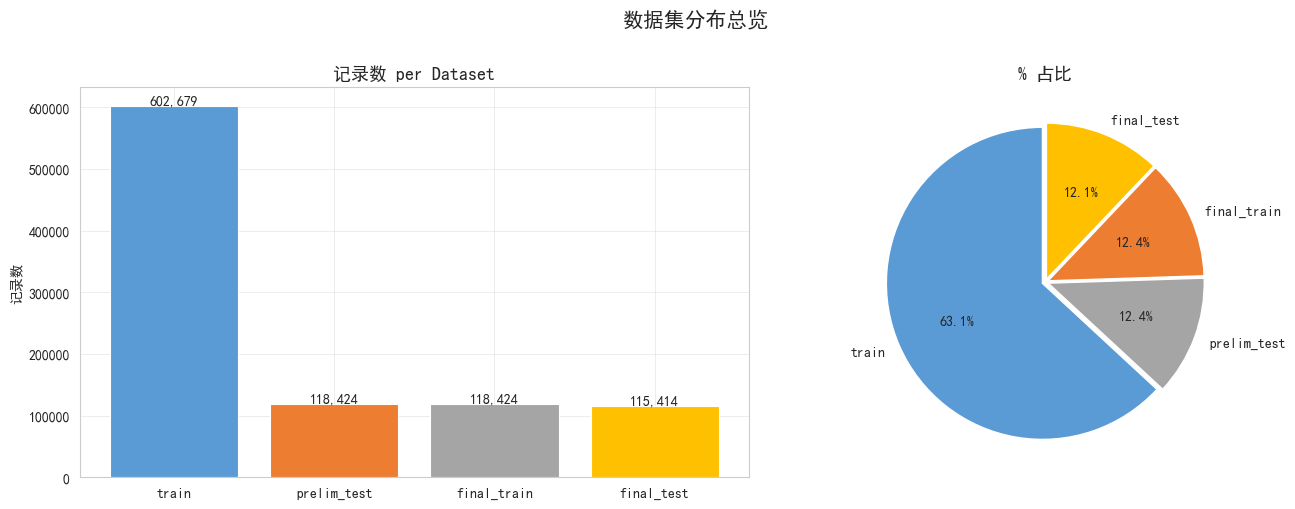

──────────────────────────────────────────────────
缺失/异常值统计 (训练集, value=-1)
──────────────────────────────────────────────────
                   total       =-1        pct
inviter_gender  721103.0  122340.0  16.965676
inviter_age     721103.0  143488.0  19.898406
inviter_level   721103.0       0.0   0.000000
voter_gender    721103.0  156383.0  21.686638
voter_age       721103.0  186521.0  25.866069
voter_level     721103.0       0.0   0.000000


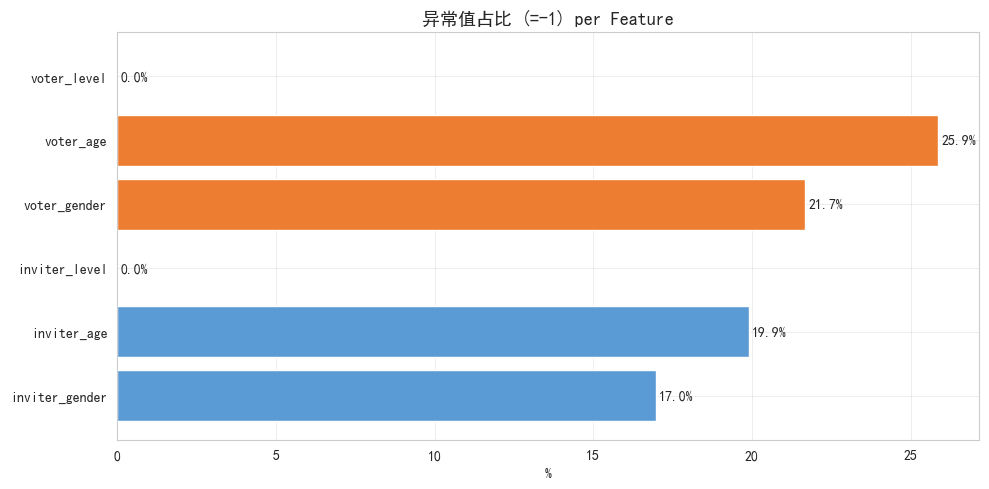


✅ Block 1 完成


In [6]:
# ============================================================
# Block 1 — 数据总览与质量检查

# 📝 绘图方式说明 (2026-06-14 与克劳德讨论):
# 本 notebook 使用 matplotlib 的「对象式 API」(fig, axes = plt.subplots)而非 pandas 的快捷 .plot() 或 plt 全局式调用:
#   - df.plot()     → 最简单，但定制多子图/颜色/字体时很痛苦
#   - plt.bar()     → 全局式，单图还行，多图时来回切 subplot 容易乱
#   - axes[0].bar() → 对象式，每张子图独立控制，16张定制图表更可控
# seaborn 只做了一件事: sns.set_style("whitegrid") 换皮肤，主力绘图仍是 matplotlib。
# networkx 负责图拓扑运算 (PageRank/度数)，不参与统计图绘制。
# ============================================================

# 1.1 各数据集规模对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dataset_counts = df_all["dataset"].value_counts()
colors_bar = ["#5B9BD5", "#ED7D31", "#A5A5A5", "#FFC000"]
axes[0].bar(dataset_counts.index, dataset_counts.values, color=colors_bar, edgecolor="white", linewidth=0.8)
axes[0].set_title("记录数 per Dataset", fontsize=13, fontweight="bold")
axes[0].set_ylabel("记录数")
for i, v in enumerate(dataset_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}", ha="center", fontsize=10)


colors_pie = ["#5B9BD5", "#A5A5A5", "#ED7D31", "#FFC000"]
wedges, texts, autotexts = axes[1].pie(
    dataset_counts.values, labels=dataset_counts.index, autopct="%1.1f%%",
    colors=colors_pie, startangle=90, explode=(0.02, 0.02, 0.02, 0.02)
)
axes[1].set_title("% 占比", fontsize=13, fontweight="bold")

fig.suptitle("数据集分布总览", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "1_dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 1.2 缺失/异常值统计（仅训练集，有完整 inviter + voter 特征）
print("─" * 50)
print("缺失/异常值统计 (训练集, value=-1)")
print("─" * 50)

missing_stats = {}
for col in ["inviter_gender", "inviter_age", "inviter_level",
            "voter_gender", "voter_age", "voter_level"]:
    total = len(df_train_all)
    neg_count = (df_train_all[col] == -1).sum()
    missing_stats[col] = {
        "total": total,
        "=-1": neg_count,
        "pct": neg_count / total * 100
    }

df_missing = pd.DataFrame(missing_stats).T
print(df_missing.to_string())

# 可视化异常值
fig, ax = plt.subplots(figsize=(10, 5))
labels = df_missing.index.tolist()
pct_values = df_missing["pct"].values
bars = ax.barh(labels, pct_values, color=["#5B9BD5"]*3 + ["#ED7D31"]*3, edgecolor="white")
ax.set_title("异常值占比 (=-1) per Feature", fontsize=13, fontweight="bold")
ax.set_xlabel("%")
for bar, pct in zip(bars, pct_values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "2_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Block 1 完成")

In [ ]:
# ============================================================
# Block 2 — 时间分析
# ============================================================

df_train_all["date"] = df_train_all["timestamp"].dt.date
df_train_all["hour"] = df_train_all["timestamp"].dt.hour
df_train_all["day_of_week"] = df_train_all["timestamp"].dt.dayofweek  # Mon=0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 2.1 每日分享数趋势
daily = df_train_all.groupby("date").size()
axes[0, 0].plot(daily.index, daily.values, color="#5B9BD5", linewidth=0.8, alpha=0.9)
axes[0, 0].fill_between(daily.index, daily.values, alpha=0.15, color="#5B9BD5")
axes[0, 0].set_title("每日分享记录数 (训练集)", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("分享数")
axes[0, 0].tick_params(axis="x", rotation=30)

# 2.2 按小时分布
hourly = df_train_all.groupby("hour").size()
axes[0, 1].bar(hourly.index, hourly.values, color="#ED7D31", edgecolor="white")
axes[0, 1].set_title("分享行为 × 小时", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("小时 (0-23)")
axes[0, 1].set_ylabel("分享数")

# 2.3 按星期分布
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = df_train_all.groupby("day_of_week").size()
axes[1, 0].bar(day_names, dow.values, color="#A5A5A5", edgecolor="white")
axes[1, 0].set_title("分享行为 × 星期", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("分享数")

# 2.4 数据集时间线对比
datasets_timeline = {
    "train":        ("2021-12-27", "2022-10-29"),
    "final_train":  ("2022-10-29", "2022-12-06"),
    "prelim_test":  ("2022-10-29", "2022-12-06"),
    "final_test":   ("2022-12-06", "2023-02-28"),
}
y_positions = list(range(len(datasets_timeline)))
colors_tl = ["#5B9BD5", "#ED7D31", "#A5A5A5", "#FFC000"]
for i, (name, (start, end)) in enumerate(datasets_timeline.items()):
    axes[1, 1].barh(i, pd.Timestamp(end) - pd.Timestamp(start),
                    left=pd.Timestamp(start), color=colors_tl[i], edgecolor="white", label=name)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    axes[1, 1].text(mid, i, name, ha="center", va="center", fontsize=9, fontweight="bold")
axes[1, 1].set_title("各数据集时间跨度", fontsize=13, fontweight="bold")
axes[1, 1].set_yticks(y_positions)
axes[1, 1].set_yticklabels(datasets_timeline.keys())
axes[1, 1].set_xlabel("时间")

fig.suptitle("时间维度分析", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "3_time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════
# 2.5 重复边检查 & 朋友圈效应分析
# 讨论日期: 2026-06-14 (南志锦 + 克劳德)
# ═══════════════════════════════════════════════════════════════
#
# ── 2.5a 三重重复: (inviter, voter, item) ──
#     同一人把同一商品发给同一人 >1次
dup_mask_3 = df_train_all.duplicated(subset=["inviter_id", "voter_id", "item_id"], keep=False)
dup_count_3 = dup_mask_3.sum()
print(f"\n三重重复边 (inviter-voter-item 相同): {dup_count_3:,} ({dup_count_3/len(df_train_all)*100:.2f}%)")
# → 结果: 0 (0.00%)
#   合理性: 人不会把同一个商品链接发给同一个人两次，发了人家看过了
#   误区: 三重=0不代表朋友圈没用，只代表不发重复链接
#
# ── 2.5b 二重重复: (inviter, voter) ──
#     同一对用户之间多次交互（不同商品），即"朋友圈"效应
dup_mask_2 = df_train_all.duplicated(subset=["inviter_id", "voter_id"], keep=False)
dup_count_2 = dup_mask_2.sum()
n_unique_pairs = df_train_all[["inviter_id", "voter_id"]].drop_duplicates().shape[0]
print(f"二重重复边 (inviter-voter 相同,不同商品): {dup_count_2:,} ({dup_count_2/len(df_train_all)*100:.2f}%)")
print(f"  唯一用户对: {n_unique_pairs:,} → 平均每对交互 {len(df_train_all)/n_unique_pairs:.1f} 次")
# → 结果: 642,329 条 (89.08%)，平均每对交互 >1 次
#   说明: 绝大多数分享行为发生在有固定交互关系的用户对之间，不是随机撒网
#   朋友圈效应极其显著 — 这对图建模是重大利好
#
# ═══════════════════════════════════════════════════════════════
# ── 2.5c 深度讨论: 朋友圈效应这么强，为什么手动做的朋友圈维度没用? ──
# ═══════════════════════════════════════════════════════════════
#
# —— 前提: 树模型的本质边界 ——
# 树能自动做的: 已有列的组合
#   例: 给树 share_out_count 和 share_in_count，它能自己发现阈值和交叉
# 树不能自动做的: 跨行聚合
#   例: 给树72万行原始记录，它不会 groupby 算出"每个用户的总分享次数"
#   所以你费劲巴拉的工程里，真正值钱的部分是聚合(必须人工做)，
#   手工交叉(role_score/share_ratio等)反而被树自己替代了。
#
# —— 核心问题 ——
# 朋友圈效应这么强(89%)，但手工构造的图特征(CN/Jaccard/AA/PA/is_friend等)
# 在LightGBM中重要性极低，AUC几乎不变。为什么?
#
# 【第一层 — 间接替代】
# 树模型从行为统计特征中自动学到了朋友圈的等价模式:
#   - share_out_count 高 + share_in_count 高 → 大概率正样本
#   - share_out_unique_voter 小 → 分享集中 → 朋友圈牢固
#   - item_id / cate_id / brand_id → 同品类用户圈层相似
#   聚合给它零件，树自己拼出了朋友圈判断。
#
# 【第二层 — 同配性 (Homophily) — "物以类聚，人以群分"】
# 进一步追问: 119个维度里没有哪个单独列叫"朋友圈"。树怎么等效出来的?
#
#   手工版 (结构嵌入):                      客观事实 (同配性):
#   "你和张三有共同好友吗?"                 "你和张三是同一种人吗?"
#         A                                       A (高分享者)
#        / \                                     /|\
#       B   C        ← 共同邻居                 B  C  D    ← 全是高分享者
#        \ /                                     \|/
#         D                                       E (也是高分享者)
#     CN=2, Jaccard=0.5                           ↑ 没有共同邻居也能形成链接
#
#   手工版假设: 链接靠"共同熟人介绍"
#   同配性揭示: 链接靠"行为相似性" — 高活跃分享者扎堆
#   LightGBM通过 inviter_share_out_count + voter_share_in_count
#   这样的交叉分裂，自动捕捉了同配性。
#
#   核心结论: 「同配性 > 结构嵌入」
#   — "你是谁"比"你认识谁"更重要
#   — 手工做的朋友圈维度都是结构嵌入, 真正的驱动力是同配性
#
# —— 证据链 ——
#   - 6个边级特征加进模型, AUC几乎不变 → 边级朋友圈冗余
#   - 4个图拓扑特征(CN/Jaccard/AA/PA)加进去也一样 → 结构嵌入冗余
#   - 52个行为统计特征才是Top-20重要性的绝对主力
#   - is_friend(硬标签)加进去AUC反降 → 统计聚合 > 已知边记忆
#   → "你是谁"比"你认识谁"更重要
#
# —— GNN的真正价值 ——
#   树模型 = 统计相关性("这种人对常出现"),
#   GNN   = 结构关系("这个节点在图中的哪个位置")。
#   冷启动场景(训练集从未同时出现的用户对) → GNN从图拓扑推理。
#   这就是朋友圈维度的真正战场，不在训练集的已知边里。
#
print("─" * 55)
print("朋友圈效应分析结论:")
print("  三重重复: 0% — 人不发重复链接")
print("  二重重复: 89% — 朋友圈极其显著")
print("  树能自动交叉已有列,但不能跨行聚合 → 聚合有价值,手工交叉被替代")
print("  核心原因: 同配性 > 结构嵌入 ('你是谁' > '你认识谁')")
print("  图特征的真正价值 → GNN + 冷启动用户对")
print("─" * 55)

print("\n✅ Block 2 完成")

训练集中出现过的用户总数: 111,770


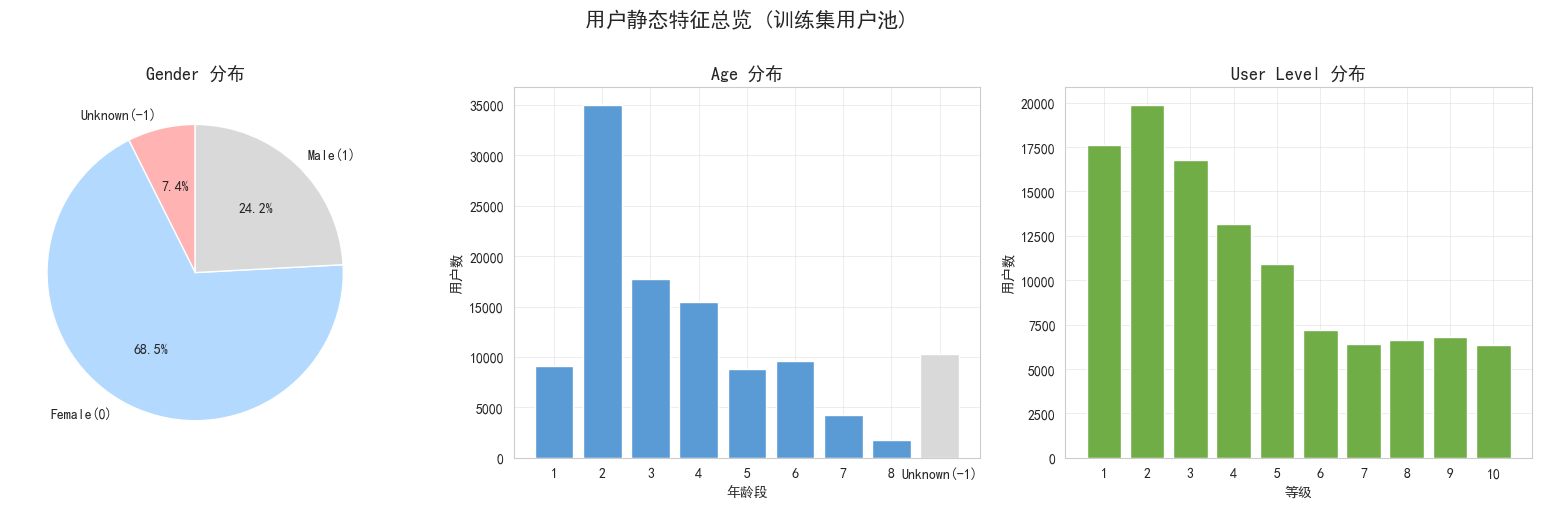


用户静态特征汇总:
Gender:  {-1: np.int64(8266), 0: np.int64(76508), 1: np.int64(26996)}
Age:     {-1: np.int64(10289), 1: np.int64(9110), 2: np.int64(34983), 3: np.int64(17692), 4: np.int64(15410), 5: np.int64(8759), 6: np.int64(9548), 7: np.int64(4268), 8: np.int64(1711)}
Level:   {1: np.int64(17638), 2: np.int64(19867), 3: np.int64(16793), 4: np.int64(13159), 5: np.int64(10890), 6: np.int64(7219), 7: np.int64(6392), 8: np.int64(6638), 9: np.int64(6827), 10: np.int64(6347)}

✅ Block 3a 完成


In [5]:
# ============================================================
# Block 3a — 用户静态特征分布 (gender / age / level)
# ============================================================

# 对训练集去重用户侧信息：每个用户只取一次
user_cols_inviter = ["inviter_id", "inviter_gender", "inviter_age", "inviter_level"]
user_cols_voter   = ["voter_id",   "voter_gender",   "voter_age",   "voter_level"]

df_inviter_unique = df_train_all[user_cols_inviter].drop_duplicates("inviter_id")
df_inviter_unique.columns = ["user_id", "gender", "age", "level"]

df_voter_unique = df_train_all[user_cols_voter].drop_duplicates("voter_id")
df_voter_unique.columns = ["user_id", "gender", "age", "level"]

# 合并去重用户池
df_user_pool = pd.concat([df_inviter_unique, df_voter_unique], ignore_index=True)
df_user_pool = df_user_pool.drop_duplicates("user_id")
print(f"训练集中出现过的用户总数: {df_user_pool.shape[0]:,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender
gender_map = {0: "Female(0)", 1: "Male(1)", -1: "Unknown(-1)"}
gender_counts = df_user_pool["gender"].value_counts().sort_index()
labels_g = [gender_map.get(k, str(k)) for k in gender_counts.index]
axes[0].pie(gender_counts.values, labels=labels_g, autopct="%1.1f%%",
            colors=["#FFB3B3", "#B3D9FF", "#D9D9D9"], startangle=90)
axes[0].set_title("Gender 分布", fontsize=13, fontweight="bold")

# Age
age_counts = df_user_pool["age"].value_counts().sort_index()
age_clean = age_counts[age_counts.index != -1]
age_missing = age_counts.get(-1, 0)
colors_age = ["#5B9BD5"] * len(age_clean)
axes[1].bar(age_clean.index.astype(str), age_clean.values, color=colors_age, edgecolor="white")
if age_missing > 0:
    axes[1].bar(["Unknown(-1)"], [age_missing], color="#D9D9D9", edgecolor="white")
axes[1].set_title("Age 分布", fontsize=13, fontweight="bold")
axes[1].set_xlabel("年龄段")
axes[1].set_ylabel("用户数")

# Level
level_counts = df_user_pool["level"].value_counts().sort_index()
axes[2].bar(level_counts.index.astype(str), level_counts.values, color="#70AD47", edgecolor="white")
axes[2].set_title("User Level 分布", fontsize=13, fontweight="bold")
axes[2].set_xlabel("等级")
axes[2].set_ylabel("用户数")

fig.suptitle("用户静态特征总览 (训练集用户池)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "4_user_static_features.png", dpi=150, bbox_inches="tight")
plt.show()

# 汇总统计
print("\n用户静态特征汇总:")
print(f"Gender:  {dict(gender_counts)}")
print(f"Age:     {dict(age_counts)}")
print(f"Level:   {dict(level_counts)}")

print("\n✅ Block 3a 完成")

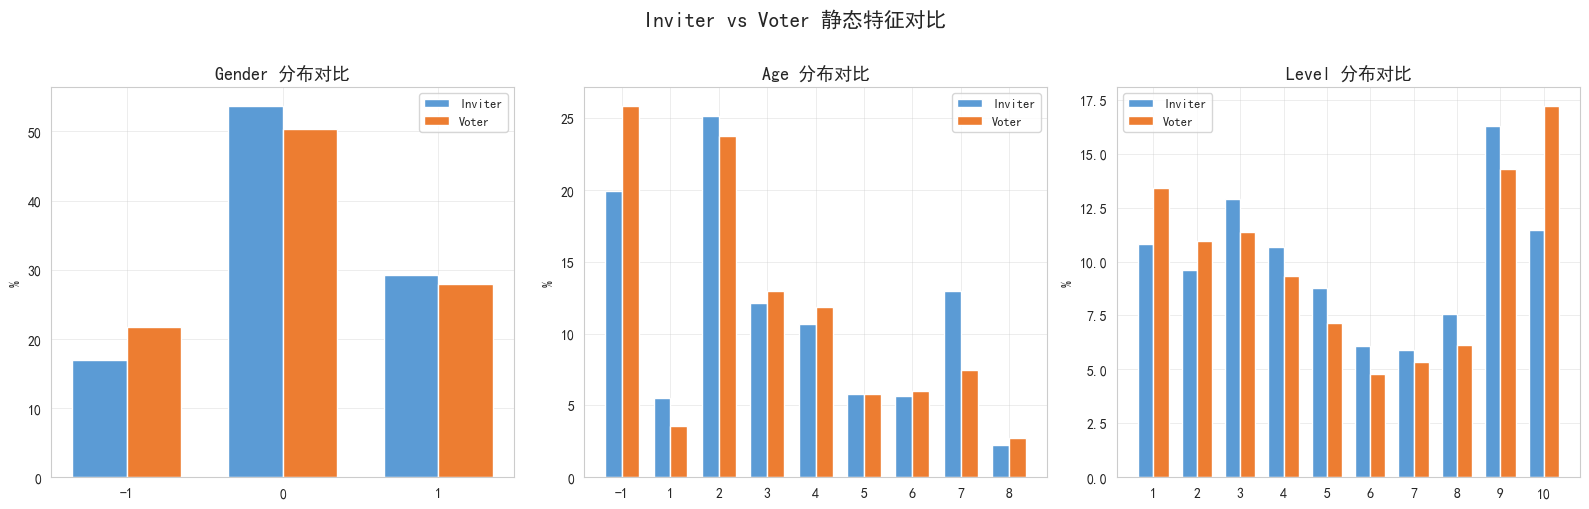


Inviter vs Voter 特征均值对比:
  gender: inviter=0.35, voter=0.36, diff=-0.00
  age: inviter=3.83, voter=3.73, diff=+0.10
  level: inviter=5.55, voter=5.59, diff=-0.04

✅ Block 3b 完成


In [6]:
# ============================================================
# Block 3b — Inviter vs Voter 特征对比
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
feature_names = ["gender", "age", "level"]
titles = ["Gender", "Age", "Level"]

for i, (feat, title) in enumerate(zip(feature_names, titles)):
    inviter_vals = df_train_all[f"inviter_{feat}"].value_counts(normalize=True).sort_index()
    voter_vals   = df_train_all[f"voter_{feat}"].value_counts(normalize=True).sort_index()

    # Align indices
    all_vals = sorted(set(inviter_vals.index) | set(voter_vals.index))
    inviter_pct = [inviter_vals.get(v, 0) * 100 for v in all_vals]
    voter_pct   = [voter_vals.get(v, 0) * 100 for v in all_vals]

    x = np.arange(len(all_vals))
    width = 0.35
    axes[i].bar(x - width/2, inviter_pct, width, label="Inviter", color="#5B9BD5", edgecolor="white")
    axes[i].bar(x + width/2, voter_pct,   width, label="Voter",   color="#ED7D31", edgecolor="white")
    axes[i].set_title(f"{title} 分布对比", fontsize=13, fontweight="bold")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_vals)
    axes[i].set_ylabel("%")
    axes[i].legend(fontsize=9)

fig.suptitle("Inviter vs Voter 静态特征对比", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "5_inviter_vs_voter.png", dpi=150, bbox_inches="tight")
plt.show()

# 数值对比
print("\nInviter vs Voter 特征均值对比:")
for feat in feature_names:
    inv_mean = df_train_all[f"inviter_{feat}"].replace(-1, np.nan).mean()
    vot_mean = df_train_all[f"voter_{feat}"].replace(-1, np.nan).mean()
    print(f"  {feat}: inviter={inv_mean:.2f}, voter={vot_mean:.2f}, diff={inv_mean - vot_mean:+.2f}")

print("\n✅ Block 3b 完成")

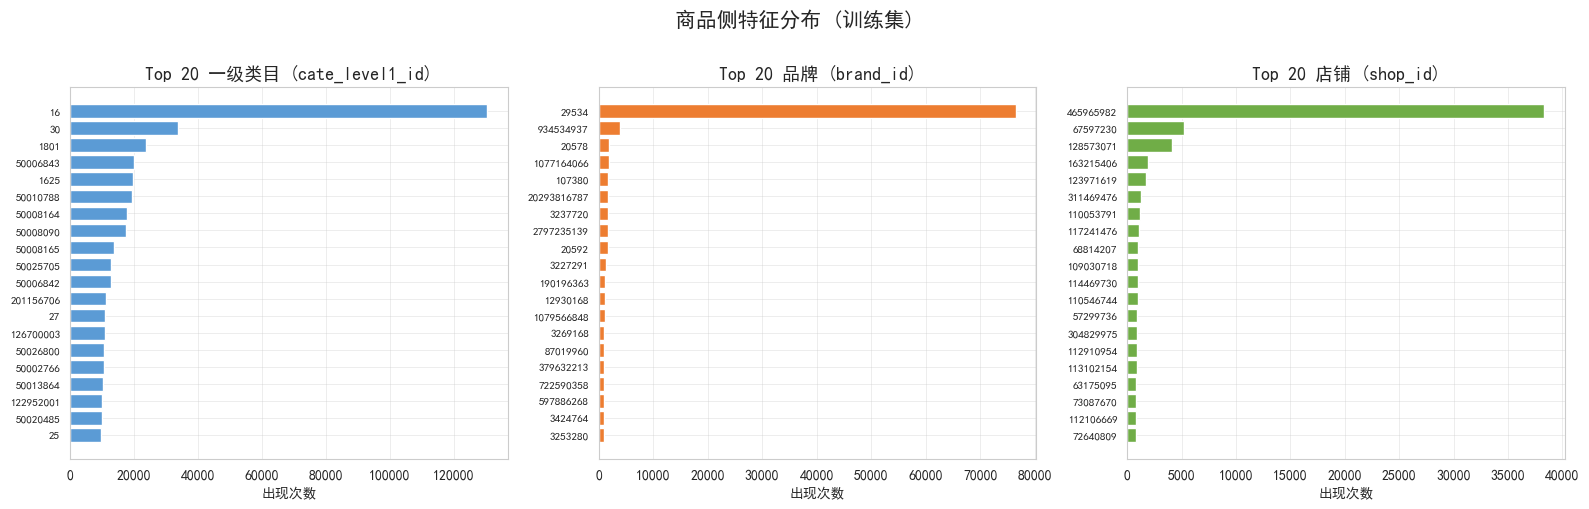


训练集商品特征基数:
  唯一商品数:        372,685
  唯一一级类目数:    139
  唯一品牌数:        79,093
  唯一店铺数:        145,874

✅ Block 3c 完成


In [7]:
# ============================================================
# Block 3c — 商品侧特征分布
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Top 20 一级类目
cate_counts = df_train_all["cate_level1_id"].value_counts().head(20)
axes[0].barh(range(len(cate_counts)), cate_counts.values, color="#5B9BD5", edgecolor="white")
axes[0].set_yticks(range(len(cate_counts)))
axes[0].set_yticklabels(cate_counts.index.astype(str), fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 一级类目 (cate_level1_id)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("出现次数")

# Top 20 品牌
brand_counts = df_train_all[df_train_all["brand_id"] != 0]["brand_id"].value_counts().head(20)
axes[1].barh(range(len(brand_counts)), brand_counts.values, color="#ED7D31", edgecolor="white")
axes[1].set_yticks(range(len(brand_counts)))
axes[1].set_yticklabels(brand_counts.index.astype(str), fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Top 20 品牌 (brand_id)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("出现次数")

# Top 20 店铺
shop_counts = df_train_all["shop_id"].value_counts().head(20)
axes[2].barh(range(len(shop_counts)), shop_counts.values, color="#70AD47", edgecolor="white")
axes[2].set_yticks(range(len(shop_counts)))
axes[2].set_yticklabels(shop_counts.index.astype(str), fontsize=8)
axes[2].invert_yaxis()
axes[2].set_title("Top 20 店铺 (shop_id)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("出现次数")

fig.suptitle("商品侧特征分布 (训练集)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "6_item_features.png", dpi=150, bbox_inches="tight")
plt.show()

# 统计量
print(f"\n训练集商品特征基数:")
print(f"  唯一商品数:        {df_train_all['item_id'].nunique():,}")
print(f"  唯一一级类目数:    {df_train_all['cate_level1_id'].nunique():,}")
print(f"  唯一品牌数:        {df_train_all['brand_id'].nunique():,}")
print(f"  唯一店铺数:        {df_train_all['shop_id'].nunique():,}")

print("\n✅ Block 3c 完成")

聚合 Inviter 侧行为特征...
  作为 Inviter 活跃的用户数: 19,612
聚合 Voter 侧行为特征...
  作为 Voter 活跃的用户数: 98,974


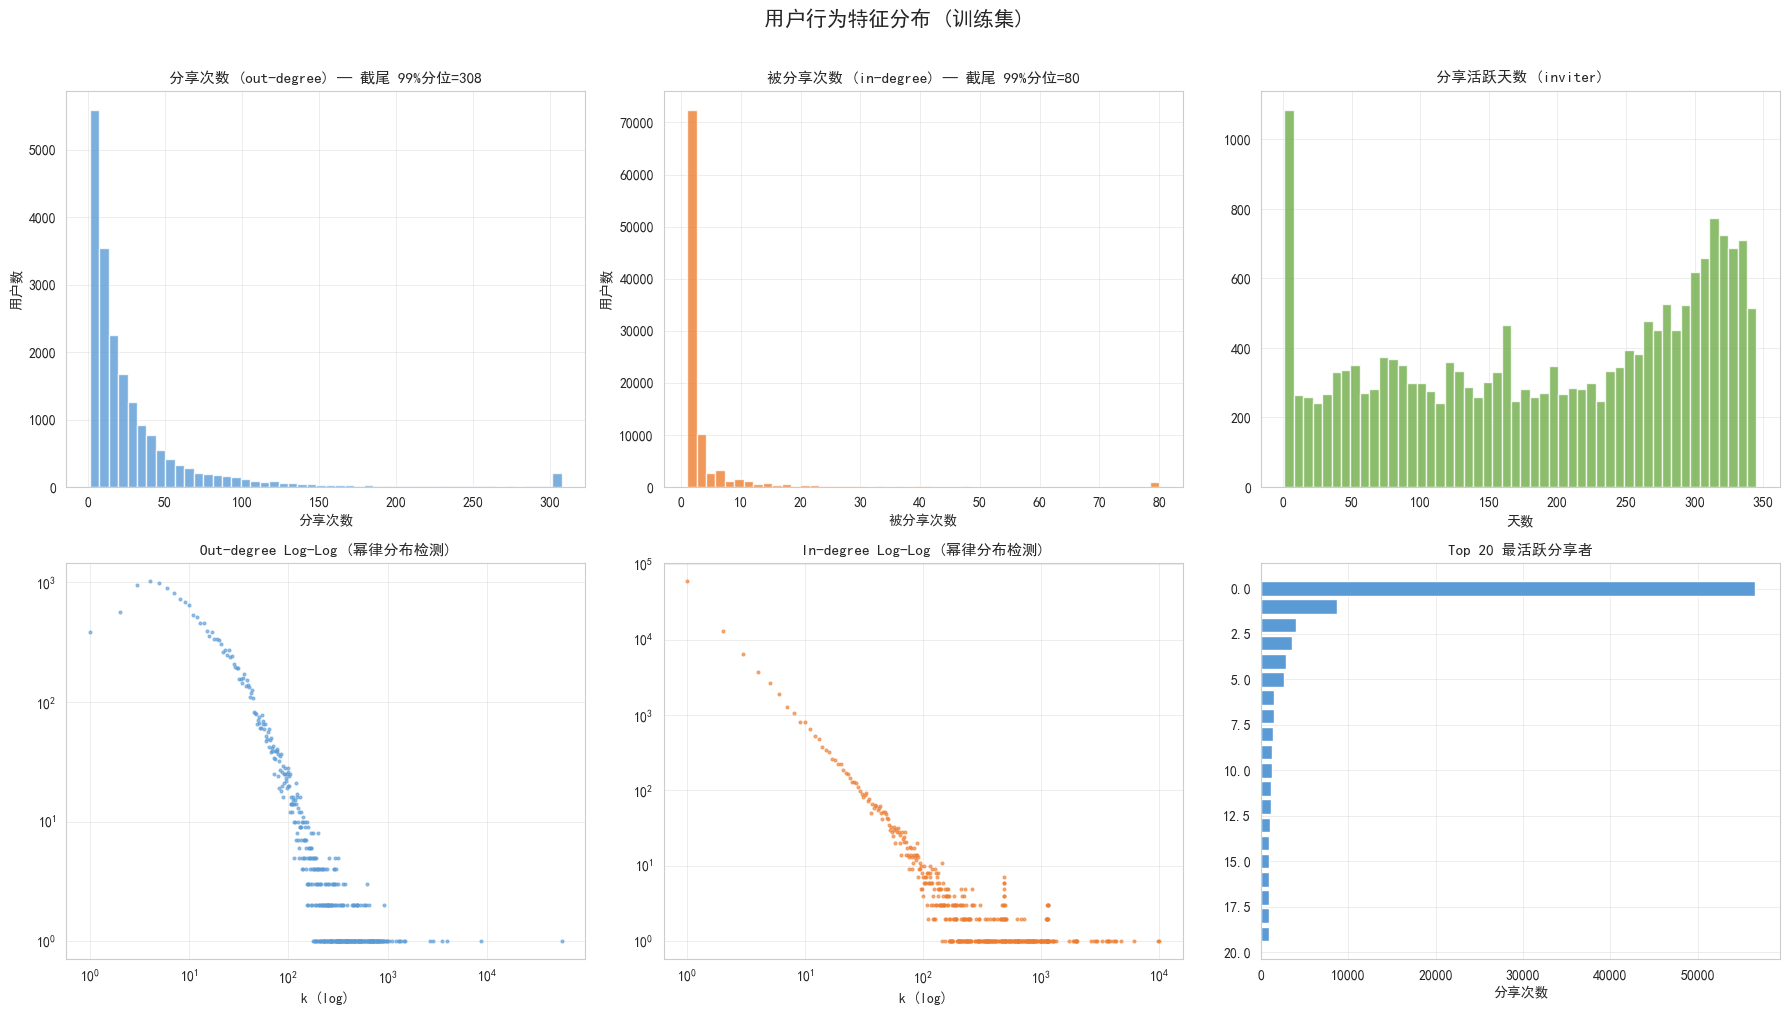


用户行为统计摘要:
  Out-degree (分享次数): mean=36.8, median=15, max=56564
  In-degree  (被分享次数): mean=7.3, median=1, max=9929

✅ Block 4a 完成


In [8]:
# ============================================================
# Block 4a — 动态行为特征：用户分享 / 被分享统计
# ============================================================

# ── 4a.1 用户分享行为聚合 (inviter 侧) ──
print("聚合 Inviter 侧行为特征...")
inviter_agg = df_train_all.groupby("inviter_id").agg(
    share_out_count=("item_id", "count"),                 # 分享总次数
    share_out_unique_item=("item_id", "nunique"),         # 分享去重商品数
    share_out_unique_voter=("voter_id", "nunique"),       # 分享去重对象数
    share_out_first_time=("timestamp", "min"),            # 首次分享时间
    share_out_last_time=("timestamp", "max"),             # 最后分享时间
).reset_index()
inviter_agg.rename(columns={"inviter_id": "user_id"}, inplace=True)
inviter_agg["share_out_active_days"] = (
    (inviter_agg["share_out_last_time"] - inviter_agg["share_out_first_time"]).dt.days + 1
)
inviter_agg["share_out_avg_per_day"] = (
    inviter_agg["share_out_count"] / inviter_agg["share_out_active_days"]
)
print(f"  作为 Inviter 活跃的用户数: {inviter_agg.shape[0]:,}")

# ── 4a.2 用户被分享行为聚合 (voter 侧) ──
print("聚合 Voter 侧行为特征...")
voter_agg = df_train_all.groupby("voter_id").agg(
    share_in_count=("item_id", "count"),                  # 被分享总次数
    share_in_unique_item=("item_id", "nunique"),          # 被分享去重商品数
    share_in_unique_inviter=("inviter_id", "nunique"),    # 被分享来源去重人数
    share_in_first_time=("timestamp", "min"),
    share_in_last_time=("timestamp", "max"),
).reset_index()
voter_agg.rename(columns={"voter_id": "user_id"}, inplace=True)
voter_agg["share_in_active_days"] = (
    (voter_agg["share_in_last_time"] - voter_agg["share_in_first_time"]).dt.days + 1
)
voter_agg["share_in_avg_per_day"] = (
    voter_agg["share_in_count"] / voter_agg["share_in_active_days"]
)
print(f"  作为 Voter 活跃的用户数: {voter_agg.shape[0]:,}")

# ── 4a.3 分布可视化 ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 分享次数分布 (log scale, 截尾 99%)
p99_out = inviter_agg["share_out_count"].quantile(0.99)
p99_in  = voter_agg["share_in_count"].quantile(0.99)

axes[0, 0].hist(inviter_agg["share_out_count"].clip(upper=p99_out), bins=50,
                color="#5B9BD5", edgecolor="white", alpha=0.8)
axes[0, 0].set_title(f"分享次数 (out-degree) — 截尾 99%分位={p99_out:.0f}", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("分享次数")
axes[0, 0].set_ylabel("用户数")

axes[0, 1].hist(voter_agg["share_in_count"].clip(upper=p99_in), bins=50,
                color="#ED7D31", edgecolor="white", alpha=0.8)
axes[0, 1].set_title(f"被分享次数 (in-degree) — 截尾 99%分位={p99_in:.0f}", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("被分享次数")
axes[0, 1].set_ylabel("用户数")

# 活跃天数分布
axes[0, 2].hist(inviter_agg["share_out_active_days"], bins=50,
                color="#70AD47", edgecolor="white", alpha=0.8)
axes[0, 2].set_title("分享活跃天数 (inviter)", fontsize=11, fontweight="bold")
axes[0, 2].set_xlabel("天数")

# Log-log 分布 (幂律诊断)
out_counts = inviter_agg["share_out_count"].value_counts().sort_index()
in_counts  = voter_agg["share_in_count"].value_counts().sort_index()
axes[1, 0].loglog(out_counts.index, out_counts.values, "o", markersize=2, color="#5B9BD5", alpha=0.6)
axes[1, 0].set_title("Out-degree Log-Log (幂律分布检测)", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("k (log)")

axes[1, 1].loglog(in_counts.index, in_counts.values, "o", markersize=2, color="#ED7D31", alpha=0.6)
axes[1, 1].set_title("In-degree Log-Log (幂律分布检测)", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("k (log)")

# Top 用户 条形图
top_n = 20
top_sharers = inviter_agg.nlargest(top_n, "share_out_count")
axes[1, 2].barh(range(top_n), top_sharers["share_out_count"].values, color="#5B9BD5", edgecolor="white")
axes[1, 2].set_title(f"Top {top_n} 最活跃分享者", fontsize=11, fontweight="bold")
axes[1, 2].set_xlabel("分享次数")
axes[1, 2].invert_yaxis()

fig.suptitle("用户行为特征分布 (训练集)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "7_user_behaviors.png", dpi=150, bbox_inches="tight")
plt.show()

# 数值统计
print("\n用户行为统计摘要:")
print(f"  Out-degree (分享次数): mean={inviter_agg['share_out_count'].mean():.1f}, "
      f"median={inviter_agg['share_out_count'].median():.0f}, max={inviter_agg['share_out_count'].max()}")
print(f"  In-degree  (被分享次数): mean={voter_agg['share_in_count'].mean():.1f}, "
      f"median={voter_agg['share_in_count'].median():.0f}, max={voter_agg['share_in_count'].max()}")

print("\n✅ Block 4a 完成")

计算商品流行度...
  训练集出现过的商品数: 372,685


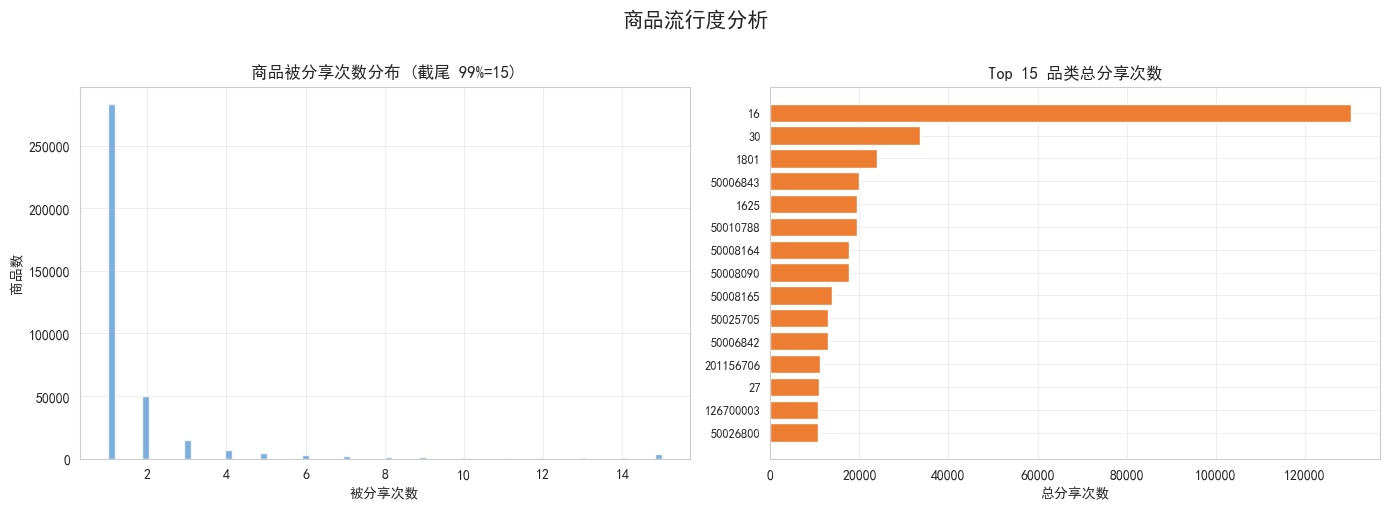

计算用户品类偏好...
  Inviter 品类偏好: 19,612 用户
  Voter 品类偏好:   98,974 用户

Top 5 品牌 (按总分享数): [0, 29534, 934534937, 20578, 1077164066]
Top 5 店铺 (按总分享数): [465965982, 67597230, 128573071, 163215406, 123971619]

✅ Block 4b 完成


In [16]:
# ============================================================
# Block 4b — 商品流行度 & 用户品类偏好
# ============================================================

# ── 4b.1 商品流行度 ──
print("计算商品流行度...")
item_pop = df_train_all.groupby("item_id").agg(
    item_share_count=("voter_id", "count"),         # 该商品被分享的总次数
    item_unique_inviter=("inviter_id", "nunique"),  # 分享该商品的人数
    item_unique_voter=("voter_id", "nunique"),      # 被分享该商品的人数
).reset_index()

# 品类级别聚合
item_cate_map = df_train_all[["item_id", "cate_level1_id", "cate_id", "brand_id", "shop_id"]].drop_duplicates("item_id")
item_pop = item_pop.merge(item_cate_map, on="item_id", how="left")

print(f"  训练集出现过的商品数: {item_pop.shape[0]:,}")

# 商品流行度分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_item = item_pop["item_share_count"].quantile(0.99)
axes[0].hist(item_pop["item_share_count"].clip(upper=p99_item), bins=80,
             color="#5B9BD5", edgecolor="white", alpha=0.8)
axes[0].set_title(f"商品被分享次数分布 (截尾 99%={p99_item:.0f})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("被分享次数")
axes[0].set_ylabel("商品数")

# Top 品类被分享次数
cate_pop = item_pop.groupby("cate_level1_id")["item_share_count"].sum().sort_values(ascending=False).head(15)
axes[1].barh(range(len(cate_pop)), cate_pop.values, color="#ED7D31", edgecolor="white")
axes[1].set_yticks(range(len(cate_pop)))
axes[1].set_yticklabels(cate_pop.index.astype(str), fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title("Top 15 品类总分享次数", fontsize=12, fontweight="bold")
axes[1].set_xlabel("总分享次数")

fig.suptitle("商品流行度分析", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "8_item_popularity.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4b.2 用户品类偏好 (每个用户最常分享的品类) ──
print("计算用户品类偏好...")

# inviter 侧品类偏好
inviter_cate = df_train_all.groupby(["inviter_id", "cate_level1_id"]).size().reset_index(name="count")
inviter_top_cate = inviter_cate.loc[
    inviter_cate.groupby("inviter_id")["count"].idxmax()
].reset_index(drop=True)
inviter_top_cate.rename(columns={
    "inviter_id": "user_id",
    "cate_level1_id": "pref_cate_inviter",
    "count": "pref_cate_inviter_count"
}, inplace=True)

# voter 侧品类偏好
voter_cate = df_train_all.groupby(["voter_id", "cate_level1_id"]).size().reset_index(name="count")
voter_top_cate = voter_cate.loc[
    voter_cate.groupby("voter_id")["count"].idxmax()
].reset_index(drop=True)
voter_top_cate.rename(columns={
    "voter_id": "user_id",
    "cate_level1_id": "pref_cate_voter",
    "count": "pref_cate_voter_count"
}, inplace=True)

print(f"  Inviter 品类偏好: {inviter_top_cate.shape[0]:,} 用户")
print(f"  Voter 品类偏好:   {voter_top_cate.shape[0]:,} 用户")

# ── 4b.3 品牌/店铺流行度 ──
brand_pop = item_pop.groupby("brand_id")["item_share_count"].sum().sort_values(ascending=False)
shop_pop  = item_pop.groupby("shop_id")["item_share_count"].sum().sort_values(ascending=False)
print(f"\nTop 5 品牌 (按总分享数): {list(brand_pop.head(5).index)}")
print(f"Top 5 店铺 (按总分享数): {list(shop_pop.head(5).index)}")

print("\n✅ Block 4b 完成")

构建有向图 (inviter → voter)...
  节点数: 111,770
  边数:   155,716
计算度中心性...
计算 PageRank (需约 1-2 分钟)...


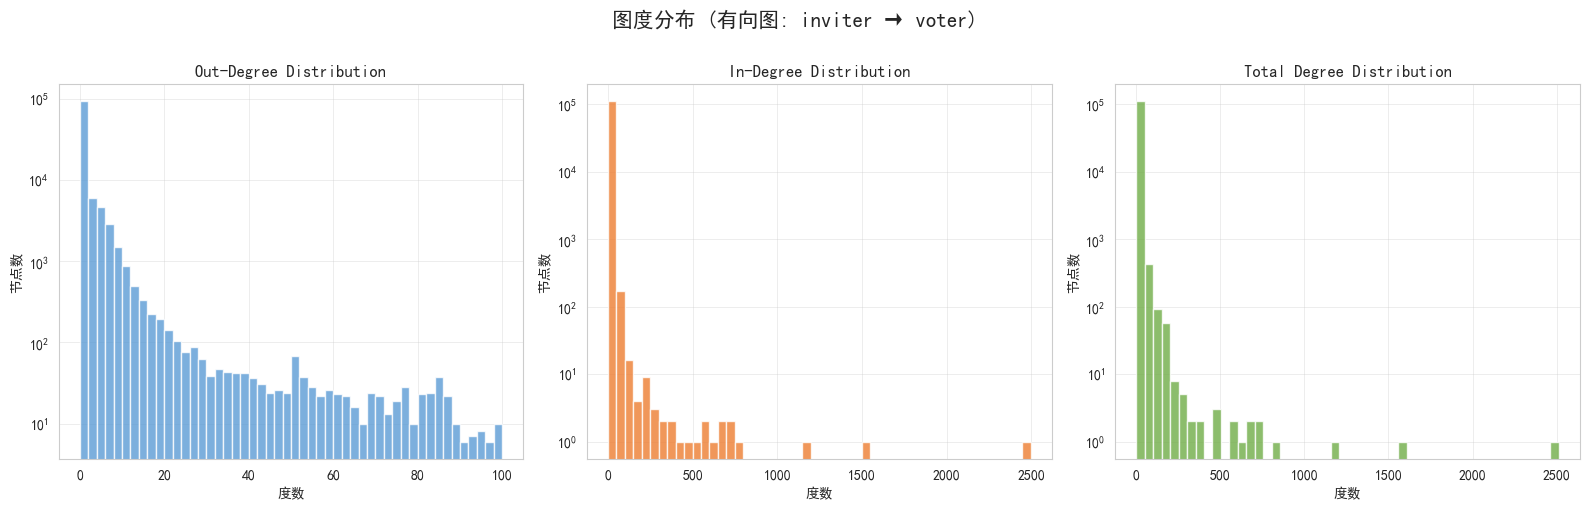

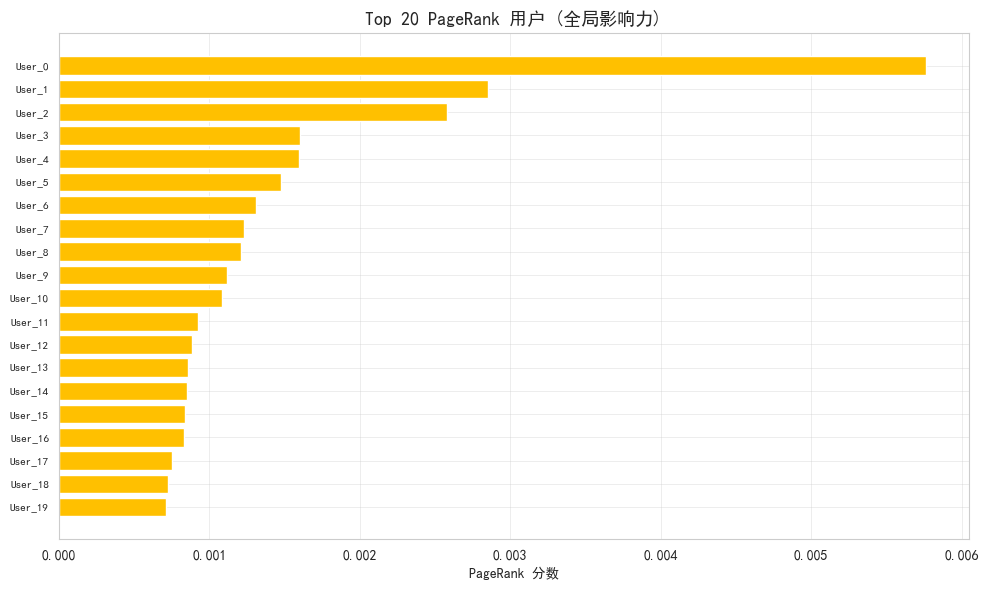


图拓扑统计:
  图密度: 0.000012
  PageRank: mean=8.946945e-06, max=5.759942e-03
  入度: mean=1.4, max=2496
  出度: mean=1.4, max=100

✅ Block 5a 完成


In [10]:
# ============================================================
# Block 5a — 图拓扑特征：构建有向图 + 度中心性 + PageRank
# ============================================================

# ── 5a.1 构建有向图 inviter → voter ──
print("构建有向图 (inviter → voter)...")
G = nx.DiGraph()

# 逐边添加 (只保留 inviter 和 voter 作为节点)
edges = df_train_all[["inviter_id", "voter_id"]].drop_duplicates().values
G.add_edges_from(edges)
print(f"  节点数: {G.number_of_nodes():,}")
print(f"  边数:   {G.number_of_edges():,}")

# ── 5a.2 度中心性 ──
print("计算度中心性...")
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())
total_degree = {n: in_degree.get(n, 0) + out_degree.get(n, 0) for n in G.nodes()}

df_degree = pd.DataFrame({
    "user_id": list(G.nodes()),
    "in_degree_graph":  [in_degree.get(n, 0) for n in G.nodes()],
    "out_degree_graph": [out_degree.get(n, 0) for n in G.nodes()],
    "total_degree_graph": [total_degree.get(n, 0) for n in G.nodes()],
})

# ── 5a.3 PageRank ──
print("计算 PageRank (需约 1-2 分钟)...")
pagerank_scores = nx.pagerank(G, alpha=0.85, max_iter=100)
df_pagerank = pd.DataFrame({
    "user_id": list(pagerank_scores.keys()),
    "pagerank": list(pagerank_scores.values()),
})

# ── 5a.4 度分布可视化 ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (data, title, color) in zip(
    axes,
    [(out_degree, "Out-Degree Distribution", "#5B9BD5"),
     (in_degree,  "In-Degree Distribution",  "#ED7D31"),
     (total_degree, "Total Degree Distribution", "#70AD47")],
):
    deg_values = list(data.values())
    ax.hist(deg_values, bins=50, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("度数")
    ax.set_ylabel("节点数")
    ax.set_yscale("log")

fig.suptitle("图度分布 (有向图: inviter → voter)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "9_graph_degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# PageRank Top 用户
top_pr = df_pagerank.nlargest(20, "pagerank")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_pr)), top_pr["pagerank"].values, color="#FFC000", edgecolor="white")
ax.set_yticks(range(len(top_pr)))
ax.set_yticklabels([f"User_{i}" for i in range(len(top_pr))], fontsize=8)
ax.invert_yaxis()
ax.set_title("Top 20 PageRank 用户 (全局影响力)", fontsize=13, fontweight="bold")
ax.set_xlabel("PageRank 分数")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_pagerank_top20.png", dpi=150, bbox_inches="tight")
plt.show()

# 统计
print(f"\n图拓扑统计:")
print(f"  图密度: {nx.density(G):.6f}")
print(f"  PageRank: mean={df_pagerank['pagerank'].mean():.6e}, "
      f"max={df_pagerank['pagerank'].max():.6e}")
print(f"  入度: mean={df_degree['in_degree_graph'].mean():.1f}, max={df_degree['in_degree_graph'].max()}")
print(f"  出度: mean={df_degree['out_degree_graph'].mean():.1f}, max={df_degree['out_degree_graph'].max()}")

del G; gc.collect()

print("\n✅ Block 5a 完成")

重建无向图用于共同邻居计算...
  无向图: 111,770 节点, 144,677 边
  去重边对: 155,716
计算共同邻居数 (需约 2-3 分钟)...
  共同邻居特征计算完成


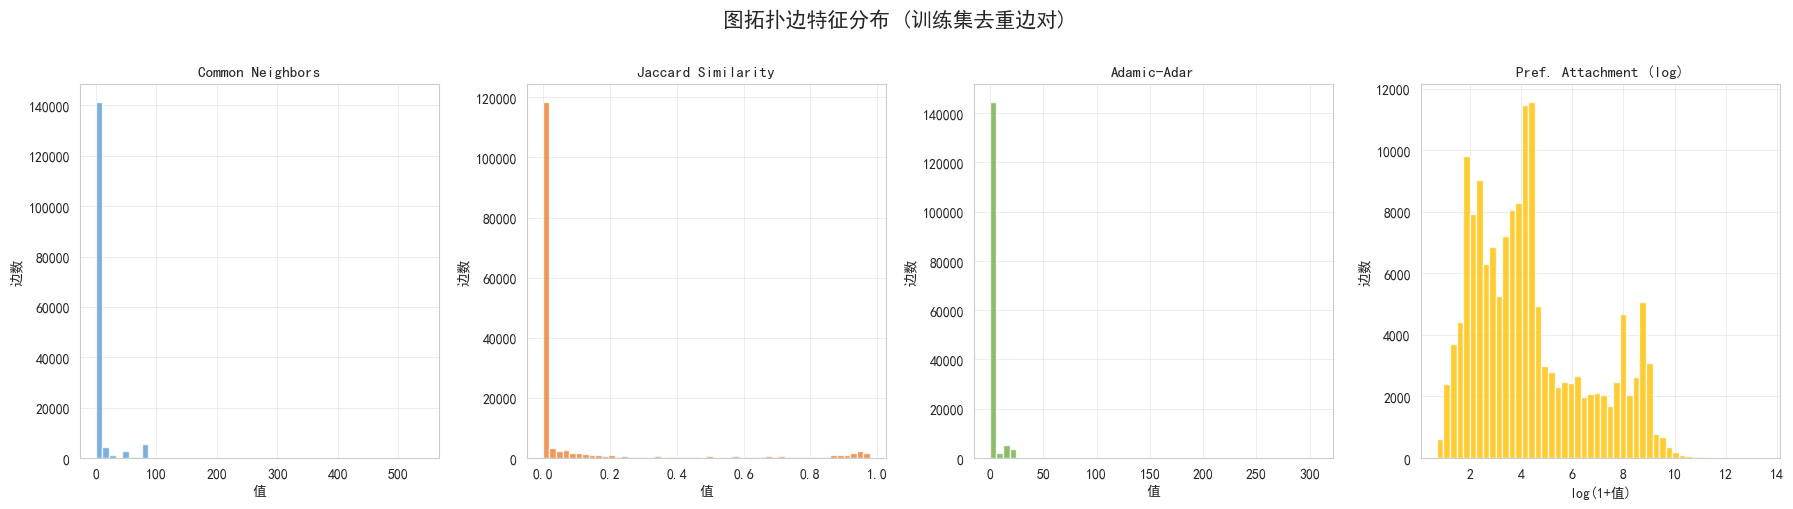


边特征统计:
  common_neighbors: mean=5.3225, median=0.00, nonzero=31.7%
  jaccard_similarity: mean=0.1037, median=0.00, nonzero=31.7%
  adamic_adar: mean=1.4372, median=0.00, nonzero=31.7%
  preferential_attachment: mean=1046.0885, median=52.00, nonzero=100.0%

✅ Block 5b 完成


In [11]:
# ============================================================
# Block 5b — 共同邻居 (Common Neighbors) 计算
# 对训练集中的每条边 (inviter, voter)，计算共同邻居数
# ============================================================

print("重建无向图用于共同邻居计算...")
G_undirected = nx.Graph()
G_undirected.add_edges_from(
    df_train_all[["inviter_id", "voter_id"]].drop_duplicates().values
)
print(f"  无向图: {G_undirected.number_of_nodes():,} 节点, {G_undirected.number_of_edges():,} 边")

# 获取所有训练边的 (inviter, voter) 对
edge_pairs = df_train_all[["inviter_id", "voter_id"]].drop_duplicates()
print(f"  去重边对: {edge_pairs.shape[0]:,}")

# 用 .apply 逐个计算共同邻居 (可能有性能开销，但清晰直观)
print("计算共同邻居数 (需约 2-3 分钟)...")
from itertools import combinations

# 提速：预计算邻居集合
neighbors = {n: set(G_undirected.neighbors(n)) for n in G_undirected.nodes()}

def count_common_neighbors(u, v):
    if u not in neighbors or v not in neighbors:
        return 0
    return len(neighbors[u] & neighbors[v])

def calc_jaccard(u, v):
    if u not in neighbors or v not in neighbors:
        return 0.0
    union = neighbors[u] | neighbors[v]
    if len(union) == 0:
        return 0.0
    return len(neighbors[u] & neighbors[v]) / len(union)

def calc_adamic_adar(u, v):
    if u not in neighbors or v not in neighbors:
        return 0.0
    common = neighbors[u] & neighbors[v]
    if len(common) == 0:
        return 0.0
    return sum(1.0 / np.log(len(neighbors[w])) for w in common if len(neighbors[w]) > 1)

def calc_preferential_attachment(u, v):
    deg_u = len(neighbors.get(u, set()))
    deg_v = len(neighbors.get(v, set()))
    return deg_u * deg_v

edge_pairs["common_neighbors"] = edge_pairs.apply(
    lambda r: count_common_neighbors(r["inviter_id"], r["voter_id"]), axis=1
)
edge_pairs["jaccard_similarity"] = edge_pairs.apply(
    lambda r: calc_jaccard(r["inviter_id"], r["voter_id"]), axis=1
)
edge_pairs["adamic_adar"] = edge_pairs.apply(
    lambda r: calc_adamic_adar(r["inviter_id"], r["voter_id"]), axis=1
)
edge_pairs["preferential_attachment"] = edge_pairs.apply(
    lambda r: calc_preferential_attachment(r["inviter_id"], r["voter_id"]), axis=1
)

print(f"  共同邻居特征计算完成")

# ── 分布可视化 ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
feature_config = [
    ("common_neighbors", "Common Neighbors", "#5B9BD5"),
    ("jaccard_similarity", "Jaccard Similarity", "#ED7D31"),
    ("adamic_adar", "Adamic-Adar", "#70AD47"),
    ("preferential_attachment", "Pref. Attachment (log)", "#FFC000"),
]

for ax, (col, title, color) in zip(axes, feature_config):
    vals = edge_pairs[col]
    if col == "preferential_attachment":
        vals = np.log1p(vals)
        ax.hist(vals, bins=50, color=color, edgecolor="white", alpha=0.8)
        ax.set_xlabel("log(1+值)")
    else:
        ax.hist(vals, bins=50, color=color, edgecolor="white", alpha=0.8)
        ax.set_xlabel("值")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("边数")

fig.suptitle("图拓扑边特征分布 (训练集去重边对)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_edge_topology_features.png", dpi=150, bbox_inches="tight")
plt.show()

# 统计
print("\n边特征统计:")
for col, _, _ in feature_config:
    vals = edge_pairs[col]
    print(f"  {col}: mean={vals.mean():.4f}, median={vals.median():.2f}, "
          f"nonzero={ (vals > 0).sum() / len(vals) * 100:.1f}%")

del G_undirected, neighbors; gc.collect()

print("\n✅ Block 5b 完成")

In [12]:
# ============================================================
# Block 6a — 用户画像表组装
# 合并：静态特征 + 行为特征 + 图拓扑特征
# ============================================================

print("组装用户画像表...")

# ── 6a.1 静态特征基准 (从 df_user_pool 取) ──
df_profile = df_user_pool.copy()  # user_id, gender, age, level

# ── 6a.2 JOIN inviter 侧行为特征 ──
df_profile = df_profile.merge(inviter_agg, on="user_id", how="left")

# ── 6a.3 JOIN voter 侧行为特征 ──
df_profile = df_profile.merge(voter_agg, on="user_id", how="left")

# ── 6a.4 JOIN 图拓扑特征 ──
df_profile = df_profile.merge(df_degree, on="user_id", how="left")
df_profile = df_profile.merge(df_pagerank, on="user_id", how="left")

# ── 6a.5 JOIN 品类偏好 ──
df_profile = df_profile.merge(inviter_top_cate, on="user_id", how="left")
df_profile = df_profile.merge(voter_top_cate, on="user_id", how="left")

# ── 6a.6 衍生特征 ──
# 分享/被分享比
df_profile["share_ratio"] = df_profile["share_out_count"].fillna(0) / (
    df_profile["share_in_count"].fillna(0) + 1
)

# 是否活跃分享者
df_profile["is_active_sharer"] = (df_profile["share_out_count"].fillna(0) > 0).astype(int)
# 是否活跃被分享者
df_profile["is_active_target"] = (df_profile["share_in_count"].fillna(0) > 0).astype(int)

# 填充未出现的数值列为 0
fill_zero_cols = [
    "share_out_count", "share_out_unique_item", "share_out_unique_voter",
    "share_out_active_days", "share_out_avg_per_day",
    "share_in_count", "share_in_unique_item", "share_in_unique_inviter",
    "share_in_active_days", "share_in_avg_per_day",
    "in_degree_graph", "out_degree_graph", "total_degree_graph",
    "pagerank",
]
for col in fill_zero_cols:
    if col in df_profile.columns:
        df_profile[col] = df_profile[col].fillna(0)

print(f"用户画像表: {df_profile.shape[0]:,} 用户 × {df_profile.shape[1]} 列")
print(f"列名: {list(df_profile.columns)}")

# ── 6a.7 保存 ──
PROFILE_PATH = PROCESSED_DIR / "user_profile.pkl"
df_profile.to_pickle(PROFILE_PATH)
print(f"\n✅ 用户画像表已保存至: {PROFILE_PATH}")

# ── 6a.8 画像表各列说明 ──
print("""
┌────────────────────────────┬──────────────────────────────────────────────────┐
│ 列名分类                   │ 说明                                             │
├────────────────────────────┼──────────────────────────────────────────────────┤
│ user_id, gender, age, level│ 静态人口属性                                     │
│ share_out_*                │ 分享行为 (out): 次数, 商品数, 对象数, 活跃天数等  │
│ share_in_*                 │ 被分享行为 (in): 次数, 商品数, 来源数, 活跃天数等 │
│ *_degree_graph             │ 图度中心性: 入度, 出度, 总度                      │
│ pagerank                   │ 全局影响力分数                                   │
│ pref_cate_*                │ 最偏好品类 (作为 inviter 和 voter)                │
│ share_ratio                │ 分享/被分享 比值                                 │
│ is_active_*                │ 是否活跃的 0/1 标记                              │
└────────────────────────────┴──────────────────────────────────────────────────┘
""")

print("✅ Block 6a 完成")

组装用户画像表...
用户画像表: 111,770 用户 × 29 列
列名: ['user_id', 'gender', 'age', 'level', 'share_out_count', 'share_out_unique_item', 'share_out_unique_voter', 'share_out_first_time', 'share_out_last_time', 'share_out_active_days', 'share_out_avg_per_day', 'share_in_count', 'share_in_unique_item', 'share_in_unique_inviter', 'share_in_first_time', 'share_in_last_time', 'share_in_active_days', 'share_in_avg_per_day', 'in_degree_graph', 'out_degree_graph', 'total_degree_graph', 'pagerank', 'pref_cate_inviter', 'pref_cate_inviter_count', 'pref_cate_voter', 'pref_cate_voter_count', 'share_ratio', 'is_active_sharer', 'is_active_target']

✅ 用户画像表已保存至: D:\GNN\processed\user_profile.pkl

┌────────────────────────────┬──────────────────────────────────────────────────┐
│ 列名分类                   │ 说明                                             │
├────────────────────────────┼──────────────────────────────────────────────────┤
│ user_id, gender, age, level│ 静态人口属性                                     │
│ share_

In [13]:
# ============================================================
# Block 6a+ — 用户画像工业化升级
# 从"事实标签"升级到"模型标签"：补充 15 个连续值特征
# ============================================================
import numpy as np
from scipy.stats import entropy

REF_DATE = pd.Timestamp("2022-12-06")

print("═" * 50)
print("Block 6a+ — 用户画像工业化升级")
print("═" * 50)

# ── 1. 时间新鲜度（Recency）— 距截止日多久没活动？ ──
print("[1/7] 时间新鲜度...")
last_out = df_train_all.groupby("inviter_id")["timestamp"].max()
last_in  = df_train_all.groupby("voter_id")["timestamp"].max()
df_profile["days_since_last_share"]   = (REF_DATE - df_profile["user_id"].map(last_out)).dt.days.fillna(-1)
df_profile["days_since_last_receive"] = (REF_DATE - df_profile["user_id"].map(last_in)).dt.days.fillna(-1)
df_profile["days_since_last_activity"] = df_profile[["days_since_last_share", "days_since_last_receive"]].min(axis=1)

# ── 2. 角色分（Role Score）— 0~1，越接近 1 越是纯分享者 ──
print("[2/7] 角色分...")
total = df_profile["share_out_count"].fillna(0) + df_profile["share_in_count"].fillna(0)
df_profile["role_score"] = np.where(total > 0, df_profile["share_out_count"].fillna(0) / total, 0.5)

# ── 3. 交互深度（Repeat Ratio）— 广撒网 vs 固定搭子 ──
print("[3/7] 交互深度...")
out_n = df_profile["share_out_count"].fillna(0)
in_n  = df_profile["share_in_count"].fillna(0)
out_u = df_profile["share_out_unique_voter"].fillna(0)
in_u  = df_profile["share_in_unique_inviter"].fillna(0)

df_profile["out_repeat_ratio"]    = np.where(out_n > 0, (out_n - out_u) / out_n, 0)
df_profile["in_repeat_ratio"]     = np.where(in_n  > 0, (in_n  - in_u)  / in_n,  0)
df_profile["avg_out_per_voter"]   = np.where(out_u > 0, out_n / out_u, 0)
df_profile["avg_in_per_inviter"]  = np.where(in_u  > 0, in_n  / in_u,  0)

# ── 4. 时间规律（Weekend / Night）— 周末型 vs 夜猫子型 ──
print("[4/7] 时间规律...")
df_train_all["is_weekend"] = (df_train_all["timestamp"].dt.dayofweek >= 5).astype(int)
df_train_all["is_night"]   = ((df_train_all["timestamp"].dt.hour >= 22) | (df_train_all["timestamp"].dt.hour <= 5)).astype(int)

inv_t = df_train_all.groupby("inviter_id").agg(a=("timestamp","count"), we=("is_weekend","sum"), ni=("is_night","sum"))
vot_t = df_train_all.groupby("voter_id").agg(a_in=("timestamp","count"), we_in=("is_weekend","sum"), ni_in=("is_night","sum"))
user_t = pd.merge(inv_t, vot_t, left_index=True, right_index=True, how="outer").fillna(0)
user_t["total"] = user_t["a"] + user_t["a_in"]
user_t["weekend_ratio"] = np.where(user_t["total"] > 0, (user_t["we"] + user_t["we_in"]) / user_t["total"], 0)
user_t["night_ratio"]   = np.where(user_t["total"] > 0, (user_t["ni"] + user_t["ni_in"]) / user_t["total"], 0)

df_profile = df_profile.merge(user_t[["weekend_ratio", "night_ratio"]], left_on="user_id", right_index=True, how="left")
df_profile["weekend_ratio"] = df_profile["weekend_ratio"].fillna(0)
df_profile["night_ratio"]   = df_profile["night_ratio"].fillna(0)

# ── 5. 品类偏好熵（Category Entropy）— 兴趣广度 ──
print("[5/7] 品类偏好...")
cate_dist = df_train_all.groupby(["inviter_id", "cate_level1_id"]).size().reset_index(name="n")
cate_dist["ratio"] = cate_dist["n"] / cate_dist.groupby("inviter_id")["n"].transform("sum")

def _entropy(ratios):
    ratios = ratios[ratios > 0]
    return float(entropy(ratios, base=np.e)) if len(ratios) > 1 else 0.0

cate_feat = pd.DataFrame({
    "cate_entropy_out":   cate_dist.groupby("inviter_id")["ratio"].apply(_entropy),
    "cate_diversity_out": cate_dist.groupby("inviter_id").size(),
    "top_cate_ratio_out": cate_dist.groupby("inviter_id")["ratio"].max(),
})
df_profile = df_profile.merge(cate_feat, left_on="user_id", right_index=True, how="left")
df_profile["cate_entropy_out"]   = df_profile["cate_entropy_out"].fillna(0)
df_profile["cate_diversity_out"] = df_profile["cate_diversity_out"].fillna(0).astype(int)
df_profile["top_cate_ratio_out"] = df_profile["top_cate_ratio_out"].fillna(0)

# ── 6. 内容多样性（Item Diversity）— 分享内容的广度 ──
print("[6/7] 内容多样性...")
df_profile["item_diversity_out"] = np.where(out_n > 0, df_profile["share_out_unique_item"].fillna(0) / out_n, 0)
df_profile["item_diversity_in"]  = np.where(in_n  > 0, df_profile["share_in_unique_item"].fillna(0)  / in_n,  0)

# ── 7. 爆发度（Burstiness）— 集中爆发 vs 稳定均匀 ──
print("[7/7] 行为爆发度...")
daily_o = df_train_all.groupby(["inviter_id", df_train_all["timestamp"].dt.date]).size()
ds = daily_o.groupby("inviter_id").agg(["mean", "std"]).fillna(0)
ds.columns = ["dm", "ds"]
ds["burstiness_out"] = np.where((ds["dm"]+ds["ds"])>0, (ds["ds"]-ds["dm"])/(ds["ds"]+ds["dm"]), 0)

daily_i = df_train_all.groupby(["voter_id", df_train_all["timestamp"].dt.date]).size()
ds_i = daily_i.groupby("voter_id").agg(["mean", "std"]).fillna(0)
ds_i.columns = ["dm_in", "ds_in"]
ds_i["burstiness_in"] = np.where((ds_i["dm_in"]+ds_i["ds_in"])>0, (ds_i["ds_in"]-ds_i["dm_in"])/(ds_i["ds_in"]+ds_i["dm_in"]), 0)

df_profile = df_profile.merge(ds[["burstiness_out"]],   left_on="user_id", right_index=True, how="left")
df_profile = df_profile.merge(ds_i[["burstiness_in"]],  left_on="user_id", right_index=True, how="left")
df_profile["burstiness_out"] = df_profile["burstiness_out"].fillna(0)
df_profile["burstiness_in"]  = df_profile["burstiness_in"].fillna(0)

# ── 保存 ──
ENRICHED_PATH = PROCESSED_DIR / "user_profile_enriched.pkl"
df_profile.to_pickle(ENRICHED_PATH)

# ── 新特征清单 ──
new_features = [
    "days_since_last_activity",
    "role_score",
    "out_repeat_ratio",
    "in_repeat_ratio",
    "avg_out_per_voter",
    "avg_in_per_inviter",
    "weekend_ratio",
    "night_ratio",
    "cate_entropy_out",
    "cate_diversity_out",
    "top_cate_ratio_out",
    "item_diversity_out",
    "item_diversity_in",
    "burstiness_out",
    "burstiness_in",
]

print(f"\n升级完成: {df_profile.shape[0]:,} 用户 × {df_profile.shape[1]} 列")
print(f"新增 {len(new_features)} 个工业化特征")
print(f"已保存至: {ENRICHED_PATH}")
print("─" * 50)
for f in new_features:
    vals = df_profile[f].dropna()
    nz = (vals != 0).mean() * 100
    print(f"  {f:28s}  mu={vals.mean():.3f}  med={vals.median():.3f}  nz={nz:.0f}%")
print("═" * 50)

══════════════════════════════════════════════════
Block 6a+ — 用户画像工业化升级
══════════════════════════════════════════════════
[1/7] 时间新鲜度...
[2/7] 角色分...
[3/7] 交互深度...
[4/7] 时间规律...
[5/7] 品类偏好...
[6/7] 内容多样性...
[7/7] 行为爆发度...

升级完成: 111,770 用户 × 46 列
新增 15 个工业化特征
已保存至: D:\GNN\processed\user_profile_enriched.pkl
──────────────────────────────────────────────────
  days_since_last_activity      mu=1.250  med=-1.000  nz=99%
  role_score                    mu=0.157  med=0.000  nz=18%
  out_repeat_ratio              mu=0.104  med=0.000  nz=17%
  in_repeat_ratio               mu=0.231  med=0.000  nz=34%
  avg_out_per_voter             mu=0.842  med=0.000  nz=18%
  avg_in_per_inviter            mu=3.047  med=1.000  nz=89%
  weekend_ratio                 mu=0.260  med=0.000  nz=45%
  night_ratio                   mu=0.151  med=0.000  nz=30%
  cate_entropy_out              mu=0.292  med=0.000  nz=17%
  cate_diversity_out            mu=1.670  med=0.000  nz=18%
  top_cate_ratio_out            mu=0.

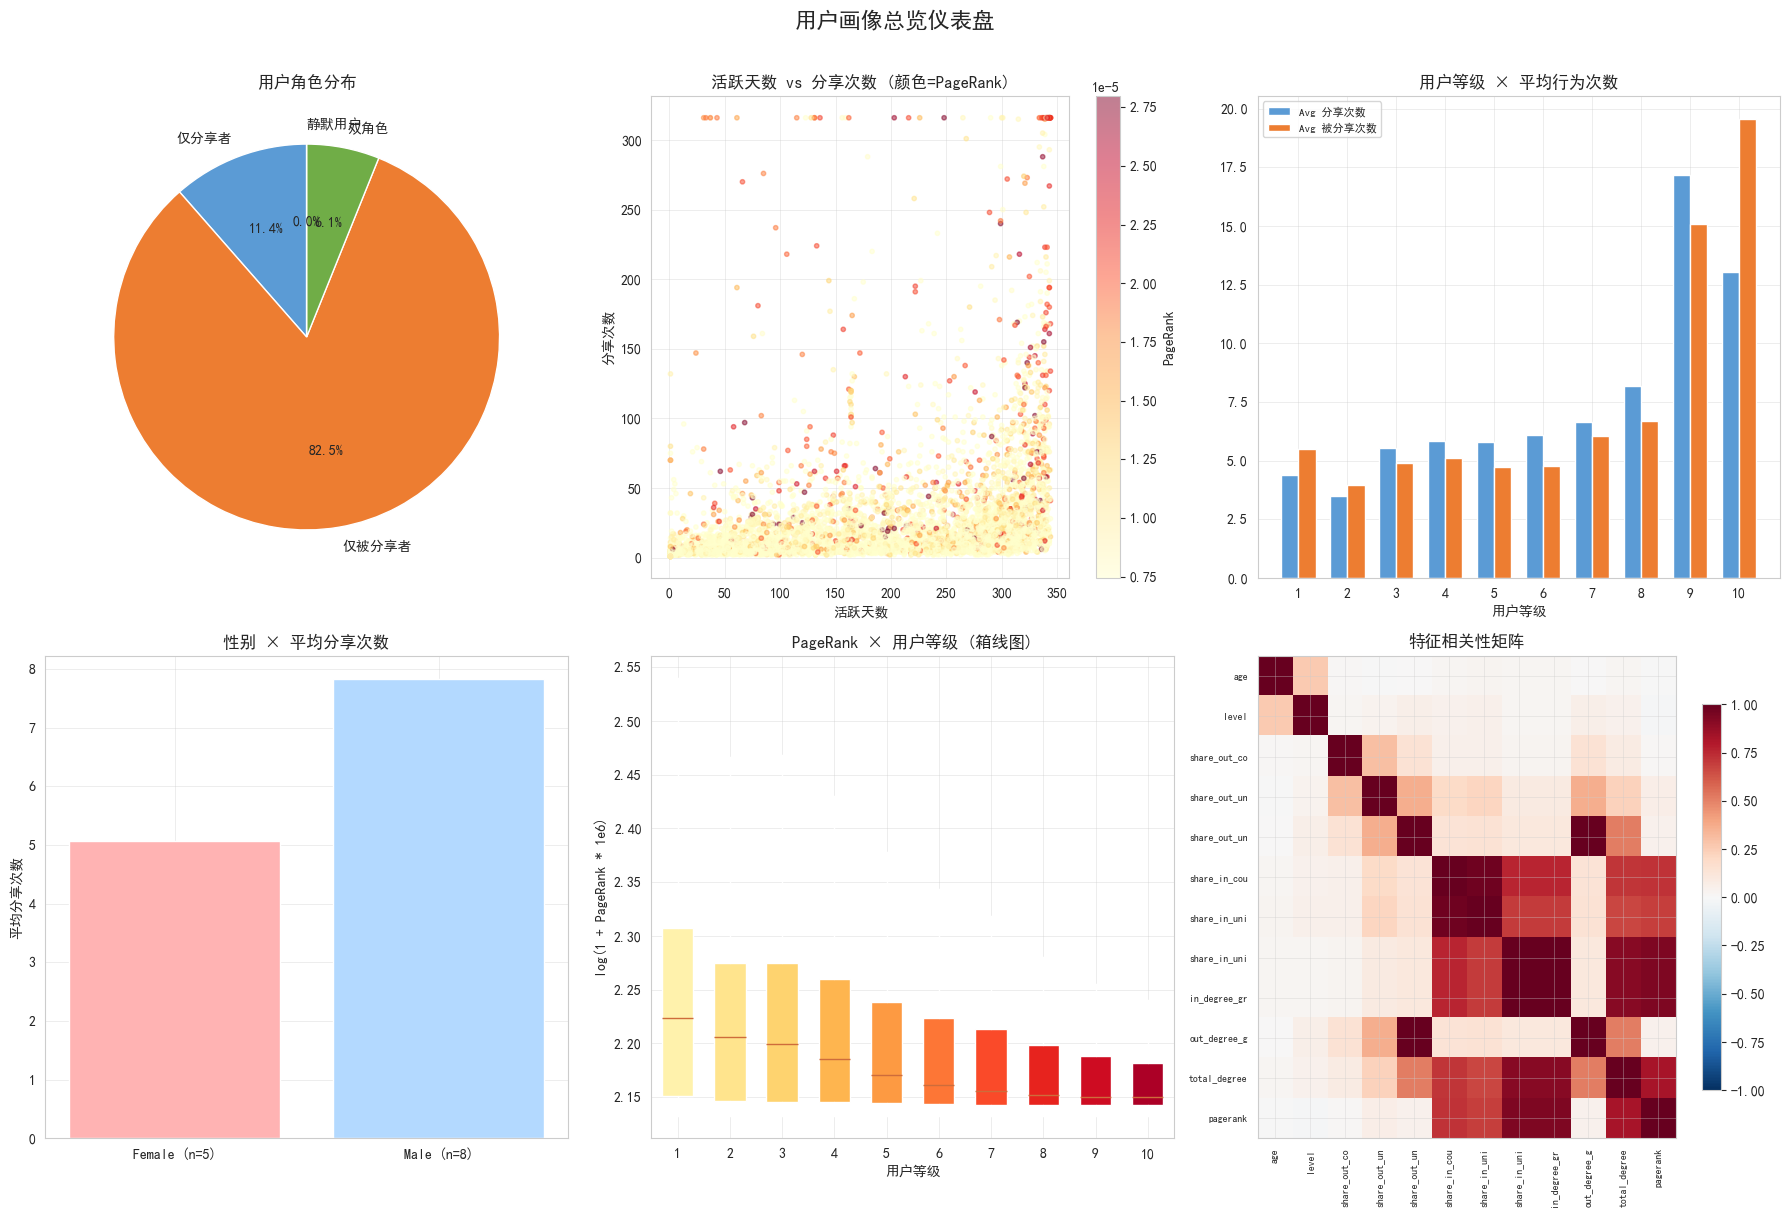

═══════════════════════════════════════════════════════
           用户画像核心数字卡片
═══════════════════════════════════════════════════════
  用户池规模:        111,770
  活跃分享者:        19,612 ( 17.5% )
  活跃被分享者:      98,974 ( 88.6% )
  人均分享次数 (非0): 36.8
  人均被分享次数 (非0): 7.3
  图平均度:          2.8
  图度中位数:        1
═══════════════════════════════════════════════════════

✅ Block 6b 完成

🎉 1.2 探索性数据分析 & 用户画像前瞻 — 全部完成


In [17]:
# ============================================================
# Block 6b — 用户画像总览仪表盘
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 活跃用户占比饼图 (分享 vs 被分享 vs 双角色 vs 静默)
active_mask_sharer  = (df_profile["is_active_sharer"] == 1) & (df_profile["is_active_target"] == 0)
active_mask_target  = (df_profile["is_active_sharer"] == 0) & (df_profile["is_active_target"] == 1)
active_mask_both    = (df_profile["is_active_sharer"] == 1) & (df_profile["is_active_target"] == 1)
active_mask_neither = (df_profile["is_active_sharer"] == 0) & (df_profile["is_active_target"] == 0)

role_counts = {
    "仅分享者": active_mask_sharer.sum(),
    "仅被分享者": active_mask_target.sum(),
    "双角色": active_mask_both.sum(),
    "静默用户": active_mask_neither.sum(),
}
axes[0, 0].pie(role_counts.values(), labels=role_counts.keys(), autopct="%1.1f%%",
               colors=["#5B9BD5", "#ED7D31", "#70AD47", "#D9D9D9"], startangle=90)
axes[0, 0].set_title("用户角色分布", fontsize=12, fontweight="bold")

# 2. 活跃天数 vs 分享次数 散点图
df_active = df_profile[df_profile["is_active_sharer"] == 1].sample(min(5000, active_mask_both.sum()))
sc = axes[0, 1].scatter(
    df_active["share_out_active_days"].clip(upper=365),
    df_active["share_out_count"].clip(upper=df_active["share_out_count"].quantile(0.99)),
    c=df_active["pagerank"].clip(upper=df_active["pagerank"].quantile(0.99)),
    cmap="YlOrRd", alpha=0.5, s=10
)
axes[0, 1].set_title("活跃天数 vs 分享次数 (颜色=PageRank)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("活跃天数")
axes[0, 1].set_ylabel("分享次数")
plt.colorbar(sc, ax=axes[0, 1], label="PageRank")

# 3. 用户等级 × 平均分享次数
level_agg = df_profile.groupby("level").agg(
    avg_out=("share_out_count", "mean"),
    avg_in=("share_in_count", "mean"),
    user_count=("user_id", "count"),
).query("level != -1").sort_index()

x = np.arange(len(level_agg))
width = 0.35
axes[0, 2].bar(x - width/2, level_agg["avg_out"], width, label="Avg 分享次数", color="#5B9BD5")
axes[0, 2].bar(x + width/2, level_agg["avg_in"],  width, label="Avg 被分享次数", color="#ED7D31")
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(level_agg.index)
axes[0, 2].set_title("用户等级 × 平均行为次数", fontsize=12, fontweight="bold")
axes[0, 2].set_xlabel("用户等级")
axes[0, 2].legend(fontsize=8)

# 4. 性别 × 活跃度对比
gender_active = df_profile[df_profile["gender"] != -1].groupby("gender").agg(
    avg_out=("share_out_count", "mean"),
    avg_in=("share_in_count", "mean"),
    avg_pagerank=("pagerank", "mean"),
)
gender_labels = {0: "Female", 1: "Male"}
for g in gender_active.index:
    axes[1, 0].bar(f"{gender_labels.get(g, g)} (n={gender_active.loc[g, 'avg_out']:.0f})",
                   gender_active.loc[g, "avg_out"], color=["#FFB3B3", "#B3D9FF"][g])
axes[1, 0].set_title("性别 × 平均分享次数", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("平均分享次数")

# 5. PageRank × 用户等级 箱线图
df_pr = df_profile[df_profile["pagerank"] > 0]
df_pr["pagerank_log"] = np.log1p(df_pr["pagerank"] * 1e6)
df_pr_plt = df_pr[df_pr["level"] > 0]
level_order = sorted(df_pr_plt["level"].unique())[:10]
pr_data = [df_pr_plt[df_pr_plt["level"] == l]["pagerank_log"].values for l in level_order]
bp = axes[1, 1].boxplot(pr_data, tick_labels=level_order, patch_artist=True,
                         showfliers=False, widths=0.6)
for patch, color in zip(bp["boxes"], sns.color_palette("YlOrRd", len(level_order))):
    patch.set_facecolor(color)
axes[1, 1].set_title("PageRank × 用户等级 (箱线图)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("用户等级")
axes[1, 1].set_ylabel("log(1 + PageRank * 1e6)")

# 6. 特征相关性矩阵 (数值特征)
corr_cols = [
    "age", "level",
    "share_out_count", "share_out_unique_item", "share_out_unique_voter",
    "share_in_count", "share_in_unique_item", "share_in_unique_inviter",
    "in_degree_graph", "out_degree_graph", "total_degree_graph", "pagerank",
]
df_corr = df_profile[corr_cols].copy()
df_corr.replace(-1, np.nan, inplace=True)
corr_matrix = df_corr.corr()

im = axes[1, 2].imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[1, 2].set_xticks(range(len(corr_cols)))
axes[1, 2].set_yticks(range(len(corr_cols)))
axes[1, 2].set_xticklabels([c[:12] for c in corr_cols], rotation=90, fontsize=7)
axes[1, 2].set_yticklabels([c[:12] for c in corr_cols], fontsize=7)
axes[1, 2].set_title("特征相关性矩阵", fontsize=12, fontweight="bold")
plt.colorbar(im, ax=axes[1, 2], shrink=0.8)

fig.suptitle("用户画像总览仪表盘", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_user_profile_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 核心数字卡片 ──
print("═" * 55)
print("           用户画像核心数字卡片")
print("═" * 55)
print(f"  用户池规模:        {df_profile.shape[0]:,}")
print(f"  活跃分享者:        {active_mask_both.sum() + active_mask_sharer.sum():,} "
      f"( {(active_mask_both.sum() + active_mask_sharer.sum()) / df_profile.shape[0] * 100:.1f}% )")
print(f"  活跃被分享者:      {active_mask_both.sum() + active_mask_target.sum():,} "
      f"( {(active_mask_both.sum() + active_mask_target.sum()) / df_profile.shape[0] * 100:.1f}% )")
print(f"  人均分享次数 (非0): {df_profile[df_profile['share_out_count']>0]['share_out_count'].mean():.1f}")
print(f"  人均被分享次数 (非0): {df_profile[df_profile['share_in_count']>0]['share_in_count'].mean():.1f}")
print(f"  图平均度:          {df_profile['total_degree_graph'].mean():.1f}")
print(f"  图度中位数:        {df_profile['total_degree_graph'].median():.0f}")
print("═" * 55)

print("\n✅ Block 6b 完成")
print("\n🎉 1.2 探索性数据分析 & 用户画像前瞻 — 全部完成")

#和克劳德讨论这个阶段的探索性数据分析的意义

这些图像化展示的东西，说实话我看了半天也就看出一点意义，感觉真正的业务意义不大。你觉得呢？虽然这确实仅仅就是一个用户画像前瞻的预备动作，是为了帮我看看用户画像的基本形态的，但是我感觉没得到什么有用的东西。



你说得对。这些图大部分是"为了画图而画图"——告诉你数据长什么样，但没告诉你怎么做预测。

  说实话，对于一个链接预测任务，真正有用的信息应该是：

  图 1（数据集分布） — 你只需要知道有 4 个数据集、规模多大，一行 print 就够了，不需要饼图。

  图 2-3（时间分析、用户画像仪表盘） — 看起来很炫，但你真的会用"用户星期几活跃"来预测两个用户会不会分享商品吗？大概率不会。

  真正值得关注的东西反而被淹没了：
  - 度分布的幂律特性（Block 4a 的 log-log 图）— 这个其实很有意义，说明少数用户贡献了大部分分享，这对图模型的选择有直接影响
  - 共同邻居 / Jaccard / Adamic-Adar 的分布（Block 5b）— 这些是链接预测的核心特征，但只给了几个直方图，没有分析它们跟标签的相关性
  - 用户画像表（Block 6a）— 表建好了，但没回答关键问题："哪种用户更可能分享？哪种用户更可能被分享？"

  建议：这个 EDA 作为数据初探够了，但如果你想要实际指导建模的洞察，下一轮分析应该聚焦在：
  1. 正样本（有分享关系）vs 负样本（无分享关系）在拓扑特征上有区分度吗？
  2. 用户画像特征（等级、活跃度）跟分享行为的相关性到底多强？
  3. 时间衰减效应 — 最近的交互比历史的交互更重要吗？